In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import Dataset
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [ ]:
def add_random_noise(img, min_noise_factor=0.05, max_noise_factor=0.15):
    noise_factor = torch.FloatTensor(1).uniform_(min_noise_factor, max_noise_factor).item()
    return img + noise_factor * torch.randn_like(img)


In [ ]:
class PairedCIFAR10(Dataset):
    def __init__(self, clean_dataset, noisy_dataset, transform=None):
        self.clean_dataset = clean_dataset
        self.noisy_dataset = noisy_dataset
        self.transform = transform

    def __len__(self):
        return len(self.clean_dataset)

    def __getitem__(self, idx):
        clean_image, _ = self.clean_dataset[idx]
        noisy_image, _ = self.noisy_dataset[idx]
        
        if self.transform:
            clean_image = self.transform(clean_image)
            noisy_image = self.transform(noisy_image)
        
        return noisy_image, clean_image


In [ ]:
transform_clean = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(), 
])

transform_noisy = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(), 
    transforms.Lambda(lambda img: add_random_noise(img, min_noise_factor=0.05, max_noise_factor=0.3))  # Add random noise
])

train_clean = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_clean)
train_noisy = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_noisy)

paired_dataset = PairedCIFAR10(train_clean, train_noisy)
data_loader = torch.utils.data.DataLoader(paired_dataset, batch_size=64, shuffle=True)

#print(f"Min value: {train_clean[1][0].min()}, Max value: {train_clean[1][0].max()}")

Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2667609..1.1763355].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22541064..1.2822783].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21679536..1.4390731].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15997075..0.9986999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90488607..1.6905793].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25248075..1.2466214].


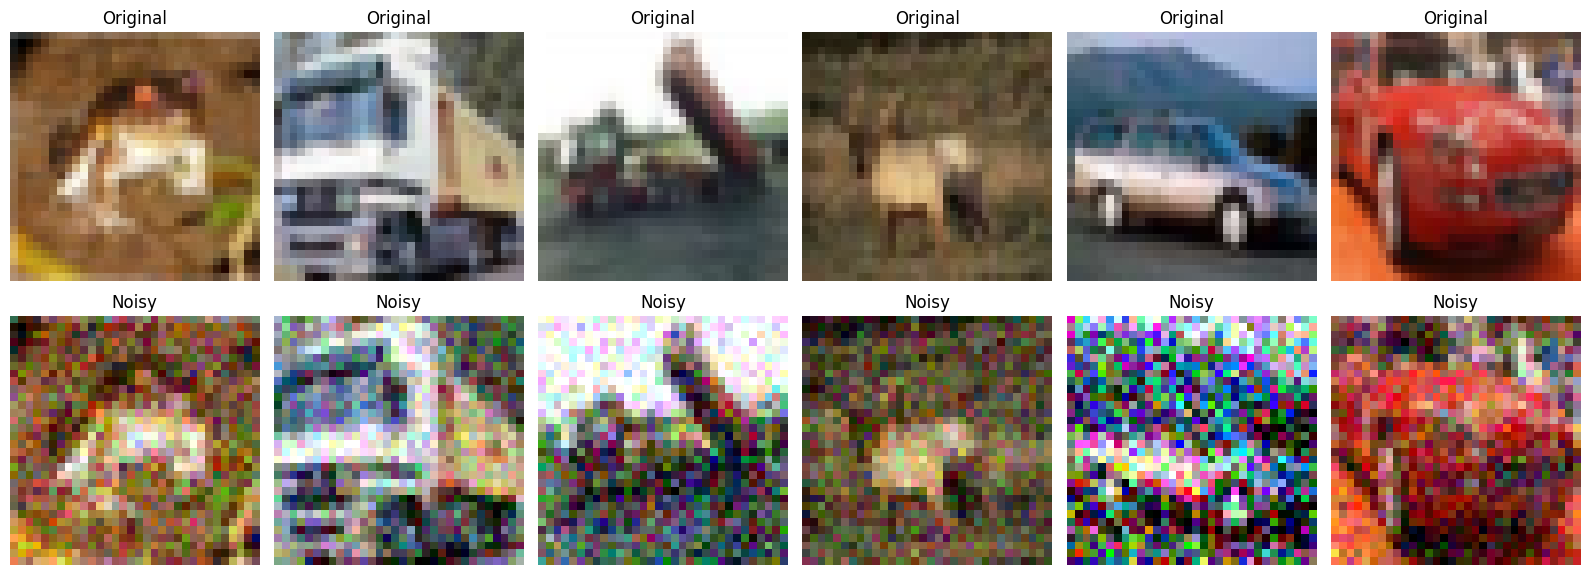

In [ ]:
# Number of images to plot
plots = 6
fig, ax = plt.subplots(2, plots, figsize=(16, 6))
count = 0

for i in range(plots):
    # Plot original image on top row
    original_image = train_clean[count][0].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    ax[0, i].imshow(original_image)
    ax[0, i].set_title('Original')
    ax[0, i].axis('off')
    
    # Plot noisy image on bottom row
    noisy_image = train_noisy[count][0].permute(1, 2, 0).numpy()
    ax[1, i].imshow(noisy_image)
    ax[1, i].set_title('Noisy')
    ax[1, i].axis('off')
    
    count += 1

plt.tight_layout()
plt.show()

In [ ]:

class Autoencoder(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=4, stride=2, padding=1), # 32x32x3 -> 16x16x16
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=1, padding=1), # 16x16x16 -> 16x16x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # 16x16x32 -> 16x16x64
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=2, stride=1, padding=0), # 16x16x64 -> 16x16x128
            nn.ReLU(),
            nn.Dropout(0.25)
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=1, padding=0), # 16x16x128 -> 16x16x64
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1), # 16x16x64 -> 16x16x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=1, padding=1), # 16x16x32 -> 16x16x16
            nn.ReLU(), 
            nn.ConvTranspose2d(16, in_channels, kernel_size=4, stride=2, padding=1), # 16x16x16 -> 32x32x3
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x) 
        return x


In [ ]:
model = Autoencoder(in_channels=3).to(device)

print(model)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(2, 2), stride=(1, 1))
    (7): ReLU()
    (8): Dropout(p=0.5, inplace=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)


In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    
    running_loss = 0.0
    
    for noisy_images, clean_images in data_loader:
        noisy_images = noisy_images.to(device)
        clean_images = clean_images.to(device)

        optimizer.zero_grad()
        
        outputs = model(noisy_images)
        
        loss = criterion(outputs, clean_images)
        
        loss.backward()
        
        optimizer.step()
        

        running_loss += loss.item() * noisy_images.size(0)
        
    # Calculate loss for entire epoch
    epoch_loss = running_loss / len(paired_dataset)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.8f}')

Epoch [1/20], Loss: 0.01325569
Epoch [2/20], Loss: 0.00681709
Epoch [3/20], Loss: 0.00586434
Epoch [4/20], Loss: 0.00539530
Epoch [5/20], Loss: 0.00510917
Epoch [6/20], Loss: 0.00494611
Epoch [7/20], Loss: 0.00476133
Epoch [8/20], Loss: 0.00462247
Epoch [9/20], Loss: 0.00449646
Epoch [10/20], Loss: 0.00441213


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'autoencoder.pth')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.51721835..1.6753161].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18610367..1.1360544].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.059034213..0.97080296].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07384443..1.2847878].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09981093..1.0645535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.28980336..1.9248879].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.

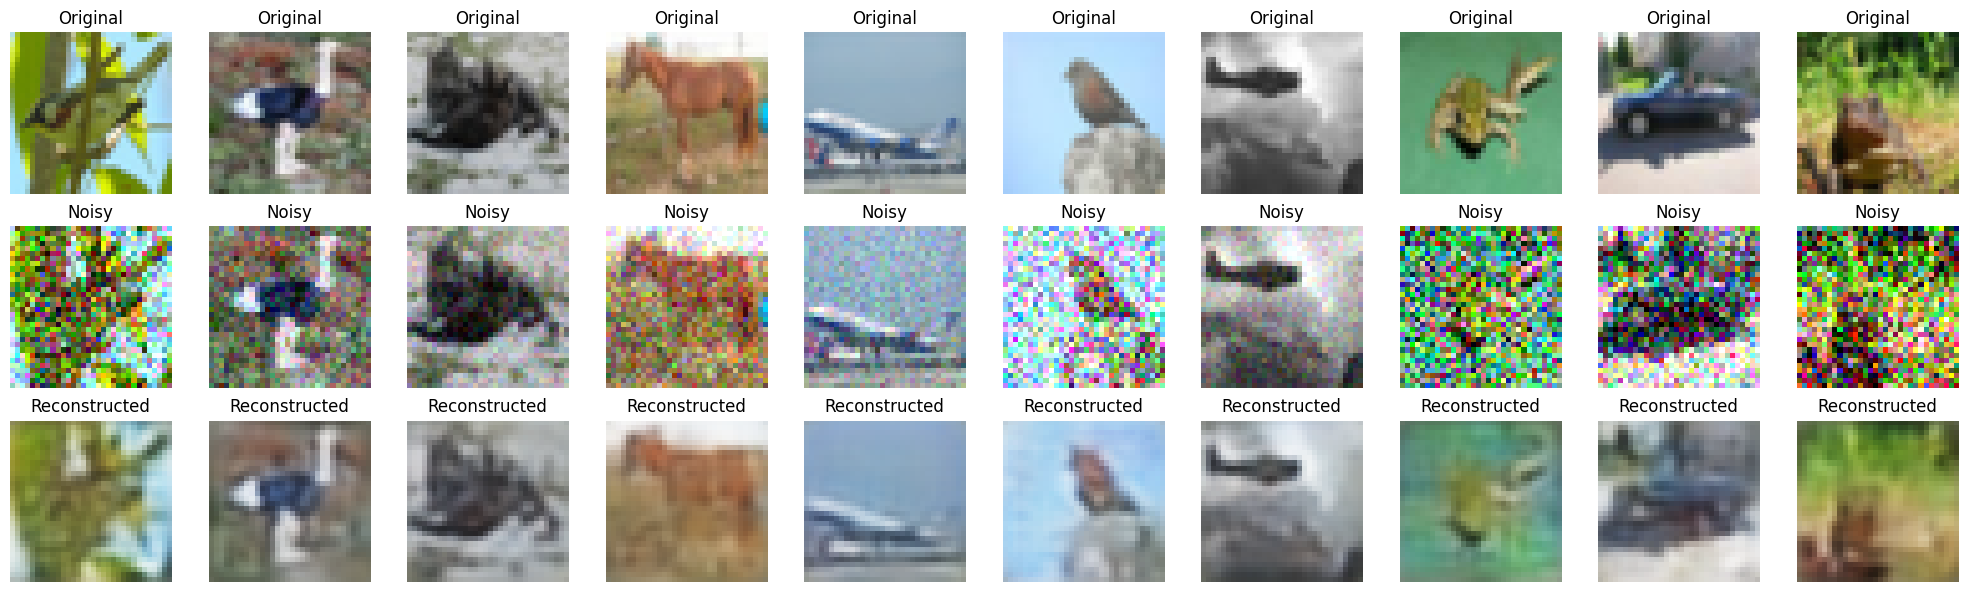

In [ ]:
def visualize_results(model, data_loader, num_images=10):
    model.eval()
    fig, axes = plt.subplots(3, num_images, figsize=(20, 6))
    
    with torch.no_grad():
        for i, (noisy_images, clean_images) in enumerate(data_loader):
            noisy_images = noisy_images.to(device)
            clean_images = clean_images.to(device)
            
            outputs = model(noisy_images)
            
            for j in range(num_images):
                axes[0, j].imshow(clean_images[j].permute(1, 2, 0).cpu())
                axes[0, j].set_title('Original')
                axes[0, j].axis('off')
                
                axes[1, j].imshow(noisy_images[j].permute(1, 2, 0).cpu())
                axes[1, j].set_title('Noisy')
                axes[1, j].axis('off')
                
                axes[2, j].imshow(outputs[j].permute(1, 2, 0).cpu())
                axes[2, j].set_title('Reconstructed')
                axes[2, j].axis('off')
            
            if i >= num_images // len(clean_images):
                break
    
    plt.tight_layout()
    plt.show()

visualize_results(model, data_loader)

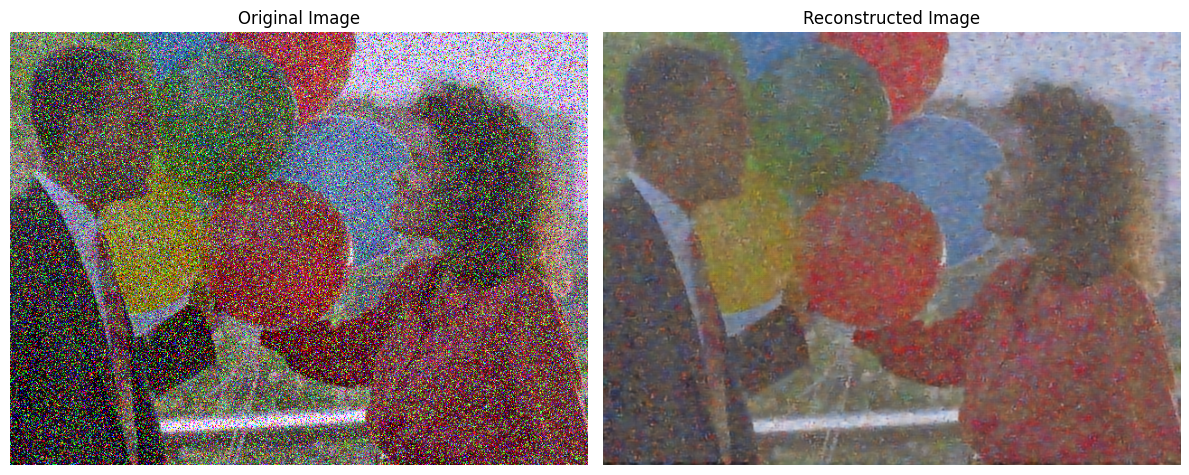

In [ ]:

image_path = './rgb3.png'  
image = Image.open(image_path).convert('RGB')

transform_full = transforms.Compose([
    transforms.ToTensor()
])

original_image = transform_full(image)

image = original_image.unsqueeze(0).to(device)

model.eval()  
with torch.no_grad(): 
    reconstructed_image = model(image)

reconstructed_image = reconstructed_image.squeeze().cpu()

original_image = transforms.ToPILImage()(original_image)
reconstructed_image = transforms.ToPILImage()(reconstructed_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(reconstructed_image)
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [4]:
num_iterations = 2
image_path = './rgb.png'

transform_full = transforms.Compose([
    transforms.ToTensor()
])

original_image = transform_full(Image.open(image_path).convert('RGB'))

image = original_image.unsqueeze(0).to(device)  # Add batch dimension

model.eval()  

with torch.no_grad():
    for _ in range(num_iterations):
        reconstructed_image = model(image)
        image = reconstructed_image.clone()

reconstructed_image = transforms.ToPILImage()(reconstructed_image.squeeze().cpu())

original_image = transforms.ToPILImage()(original_image)

# Display the original and reconstructed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(reconstructed_image)
axes[1].set_title('Reconstructed Image ({} iterations)'.format(num_iterations))
axes[1].axis('off')
plt.tight_layout()
plt.show()

NameError: name 'device' is not defined